In [ ]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
from helper import *


set_seed(42)
merged_building_df = pd.read_csv('/home/theo/Desktop/CESI_DUTh/XAI_Energy_Consumption_Prediction/Data/merged_nord_with_power.csv')


# 2. Extract separate datasets for each metric
metric_datasets = extract_metric_datasets(merged_building_df)

# 3. Access individual datasets via dictionary keys
co2_df = metric_datasets.get('CO2 indoor')
humidity_df = metric_datasets.get('HUM indoor')
temp_df = metric_datasets.get('TMP indoor')

df = merged_building_df

🔑 All random seeds set to: 42


In [2]:
# df = df.drop(columns=['Horodatage_Fin', 'Horodatage_Début'])
df.head()

,Date and Time,TMP indoor t07,HUM indoor t07,CO2 indoor t07,VOCT indoor t07,DBAA indoor t07,DBAP indoor t07,LIGHT_LUX indoor t07,OCCUPANCY_RATE indoor t07,TMP indoor mediterranee_tribord,...,CO2 indoor pacifique_tribord,VOCT indoor pacifique_tribord,DBAA indoor pacifique_tribord,DBAP indoor pacifique_tribord,LIGHT_LUX indoor pacifique_tribord,OCCUPANCY_RATE indoor pacifique_tribord,Horodatage_Début,Valeur,Consommation,Horodatage_Fin
0,2026-03-01 00:00:00,16.0,57.0,264.0,17.0,37.0,44.0,0.0,0.0,17.2,...,127.0,15.0,36.0,40.0,0.0,0.0,2026-03-01 00:00:00,2.0,0.166667,2026-03-01 00:10:00
1,2026-03-01 00:10:00,16.0,56.0,272.0,30.0,37.0,48.0,0.0,0.0,17.2,...,108.0,15.0,37.0,42.0,0.0,0.0,2026-03-01 00:10:00,3.0,0.250000,2026-03-01 00:20:00
2,2026-03-01 00:20:00,15.9,56.0,263.0,31.0,38.0,47.0,0.0,0.0,17.2,...,124.0,16.0,37.0,44.0,5.0,0.0,2026-03-01 00:20:00,3.0,0.250000,2026-03-01 00:30:00
3,2026-03-01 00:30:00,15.9,56.0,274.0,23.0,38.0,50.0,0.0,0.0,17.2,...,115.0,16.0,37.0,44.0,0.0,0.0,2026-03-01 00:30:00,3.0,0.250000,2026-03-01 00:40:00
4,2026-03-01 00:40:00,15.9,56.0,279.0,25.0,38.0,50.0,0.0,0.0,17.2,...,111.0,16.0,37.0,41.0,0.0,0.0,2026-03-01 00:40:00,2.0,0.166667,2026-03-01 00:50:00


In [3]:
len(df)

9648

In [4]:
df.isnull().sum()

Date and Time                                0
TMP indoor t07                             761
HUM indoor t07                             761
CO2 indoor t07                             761
VOCT indoor t07                            761
                                          ... 
OCCUPANCY_RATE indoor pacifique_tribord    860
Horodatage_Début                             0
Valeur                                       0
Consommation                                 0
Horodatage_Fin                               0
Length: 105, dtype: int64

## 1. Setup PyTorch Environment
Import essential PyTorch libraries and ensure CUDA access if available.

In [5]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

PyTorch Version: 2.5.1+cu124
Using device: cuda


## 2. Prepare Data
Handle missing values, isolate the `Consommation` target variable, and scale the features symmetrically using `StandardScaler`.

In [6]:
# Drop datetime strings (not numeric) and 'Valeur' (excluded: it leaks
# information about the target, e.g. it's another representation of
# Consommation, so keeping it as an input feature would let the model
# 'cheat' instead of learning from the real predictive signals).
cols_to_drop = ['Date and Time', 'Horodatage_Début', 'Horodatage_Fin', 'Valeur']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_numeric = df.drop(columns=cols_to_drop)

# Forward fill then backward fill nicely handles sequence missing data gaps!
df_numeric = df_numeric.ffill().bfill()

# Target column: Consommation is what we want to predict.
target_col_name = 'Consommation'
assert target_col_name in df_numeric.columns, f"'{target_col_name}' not found in dataframe columns!"
target_idx = df_numeric.columns.get_loc(target_col_name)

# Standardize to 0 mean and 1 variance
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric.values)
print(f"Transformed sequence shape: {data_scaled.shape}")

Transformed sequence shape: (9648, 101)


## 3. Dataset and DataLoader
Windowing the time-series arrays and batching them for optimal LSTM sequence prediction! We use `sklearn.model_selection.train_test_split` (with `shuffle=False`) to carve the data into **train / validation / test** sets in chronological order, avoiding sequential leakage over our chronological timeline that a randomly-shuffled split would introduce.

In [7]:
from sklearn.model_selection import train_test_split

class PowerConsumptionDataset(Dataset):
    def __init__(self, data, target_col_idx, seq_length=12):
        self.data = data
        self.target_col_idx = target_col_idx
        self.seq_length = seq_length
        
    def __len__(self):
        return len(self.data) - self.seq_length
        
    def __getitem__(self, idx):
        # Input history (e.g. past 2 hours block)
        x = self.data[idx : idx + self.seq_length, :]
        # Output target prediction (next value in line!)
        y = self.data[idx + self.seq_length, self.target_col_idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

seq_length = 12 
dataset = PowerConsumptionDataset(data_scaled, target_col_idx=target_idx, seq_length=seq_length)

# --- Train / Val / Test split via train_test_split -----------------------
# We split on the *index* of each window, not on the raw rows, so windows
# never straddle a split boundary. shuffle=False keeps the three sets in
# chronological order (train -> val -> test), which is what you want for
# time-series data: shuffling would let a validation/test window's target
# leak into a training window's input history (and vice versa).
#
# Target ratios: 70% train / 15% val / 15% test.
all_indices = np.arange(len(dataset))

train_val_idx, test_idx = train_test_split(
    all_indices, test_size=0.15, shuffle=False
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.15 / 0.85, shuffle=False  # 0.15/0.85 ~ 0.176 -> 15% of the total
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

n_total = len(dataset)
print(f"Total windows: {n_total}")
print(f"Train: {len(train_dataset)} ({len(train_dataset)/n_total:.1%}) | "
      f"Val: {len(val_dataset)} ({len(val_dataset)/n_total:.1%}) | "
      f"Test: {len(test_dataset)} ({len(test_dataset)/n_total:.1%})")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Total windows: 9636
Train: 6744 (70.0%) | Val: 1446 (15.0%) | Test: 1446 (15.0%)
Train batches: 106 | Val batches: 23 | Test batches: 23


## 4. LSTM Architecture
A powerful recurrent architecture to learn memory from historical sensor/power dynamics, resolving common gradient loss patterns!

In [8]:
from models.RNN import RNNModel
from models.CNN import CNNModel
from models.MLP import MLPModel

input_size = data_scaled.shape[1]
hidden_size = 256
num_layers = 2
num_filters=128
kernel_size=9

# model = RNNModel(input_size, hidden_size, num_layers).to(device)
model = CNNModel(input_size, num_filters, kernel_size).to(device)

input_size = data_scaled.shape[1]
model = MLPModel(input_size, seq_length).to(device)
print(model)

MLPModel(
  (net): Sequential(
    (0): Linear(in_features=1212, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=158, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=158, out_features=1, bias=True)
  )
)


## 5. Iteration Engine
Initialize parameters, process sequential matrices efficiently across our computation `device`, capture backward gradients to mathematically hone errors! Training uses the **train** set for gradient updates and the **validation** set to monitor generalization each epoch. The **test** set is held out entirely and is only touched once, in the final evaluation below.

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

train_losses = []
val_losses = []

print(f"Starting neural convergence loop on {device}...")

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)
    
    # Eval Step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), y_batch)
            val_loss += loss.item() * X_batch.size(0)
            
    val_loss /= len(val_dataset)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:02d}/{num_epochs}], Train MSE: {train_loss:.4f}, Val MSE: {val_loss:.4f}')

print("Training fully concluded!")

Starting neural convergence loop on cuda...
Epoch [01/20], Train MSE: 0.2826, Val MSE: 0.1045
Epoch [05/20], Train MSE: 0.0925, Val MSE: 0.1073
Epoch [10/20], Train MSE: 0.0778, Val MSE: 0.0765
Epoch [15/20], Train MSE: 0.0630, Val MSE: 0.0809
Epoch [20/20], Train MSE: 0.0520, Val MSE: 0.0794
Training fully concluded!


## 6. Metric Tracking Graphs
Let's review how closely the model adjusted to our training sequence!

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training MSE', color='blue')
plt.plot(val_losses, label='Validation MSE', color='orange')
plt.title('LSTM Sequence MSE Validation Journey')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.grid(True)
plt.show()

<Figure size 1000x500 with 1 Axes>

## 7. Model Predictions on Test Set
Predict only on the held-out **test** set (never seen during training or for hyperparameter/epoch monitoring) and visualize the model's accuracy on unseen future sequential data!

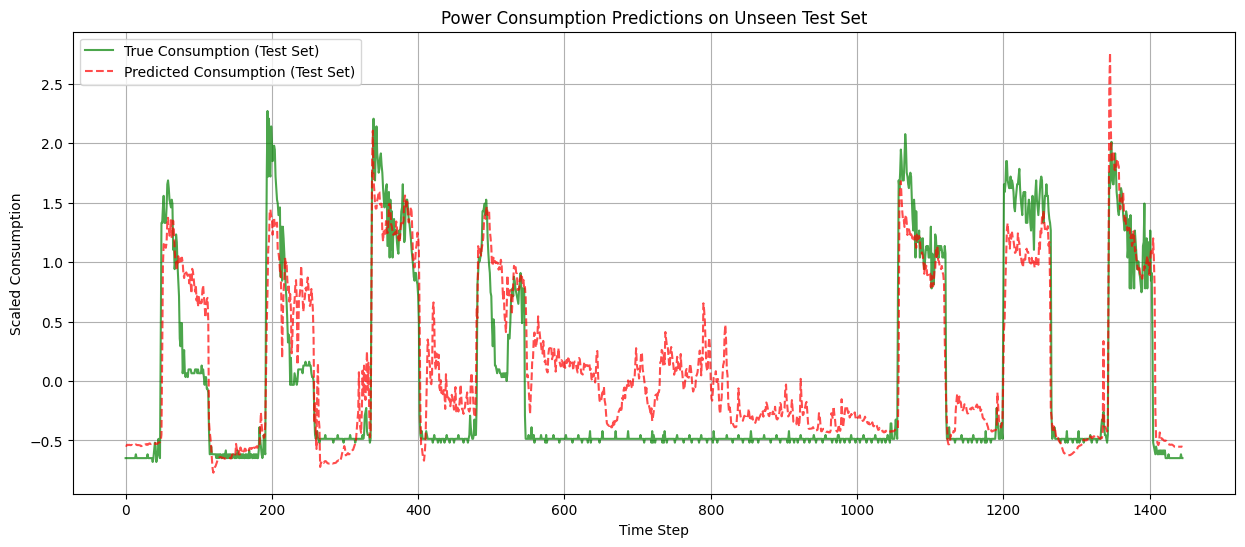

In [11]:
model.eval()
test_predictions = []
test_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        test_predictions.extend(outputs.squeeze().cpu().numpy())
        test_actuals.extend(y_batch.numpy())

plt.figure(figsize=(15, 6))
plt.plot(test_actuals, label='True Consumption (Test Set)', alpha=0.7, color='green')
plt.plot(test_predictions, label='Predicted Consumption (Test Set)', alpha=0.7, color='red', linestyle='--')
plt.title('Power Consumption Predictions on Unseen Test Set')
plt.xlabel('Time Step')
plt.ylabel('Scaled Consumption')
plt.legend()
plt.grid(True)
plt.show()


## 8. Test Set Evaluation Metrics
Quantify how well the LSTM generalizes to unseen data using **MAE**, **MSE**, **NRMSE**, and **R²**, computed in the original (physical) units of `Consommation` by inverting the `StandardScaler` transform.


In [12]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

def inverse_transform_target(values_scaled, scaler, col_idx):
    """Invert StandardScaler scaling for a single column (the target)."""
    mean = scaler.mean_[col_idx]
    scale = scaler.scale_[col_idx]
    return values_scaled * scale + mean

# Convert predictions/actuals back to original (physical) units so the
# metrics below are interpretable in real consumption units, not z-scores.
test_predictions_orig = inverse_transform_target(test_predictions, scaler, target_idx)
test_actuals_orig = inverse_transform_target(test_actuals, scaler, target_idx)

mae = mean_absolute_error(test_actuals_orig, test_predictions_orig)
mse = mean_squared_error(test_actuals_orig, test_predictions_orig)
rmse = np.sqrt(mse)

# NRMSE = RMSE normalized by the range (max - min) of the true values.
# This expresses the error as a fraction of the total spread of the target,
# making it comparable across datasets/units.
value_range = test_actuals_orig.max() - test_actuals_orig.min()
nrmse = rmse / value_range if value_range != 0 else float('nan')

r2 = r2_score(test_actuals_orig, test_predictions_orig)

print("Test Set Performance (original units)")
print("-" * 40)
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"NRMSE : {nrmse:.4f}  (RMSE / (max - min) of true values)")
print(f"R2    : {r2:.4f}")


Test Set Performance (original units)
----------------------------------------
MAE   : 0.7950
MSE   : 1.0949
RMSE  : 1.0464
NRMSE : 0.1380  (RMSE / (max - min) of true values)
R2    : 0.7398


## 9. SHAP Feature Importance
Use `shap.GradientExplainer` (works directly with PyTorch models, including recurrent layers) to estimate how much each input feature contributes to the LSTM's predictions on the **test** set. Since each sample is a sequence of `seq_length` past timesteps, we collapse the time dimension by summing absolute SHAP values across timesteps, giving one importance score per feature per sequence.

In [13]:
import shap
import copy

feature_names = df_numeric.columns.tolist()

# GradientExplainer needs a "background" set of sequences (reference distribution)
# and the sequences we actually want explanations for.
n_background = 100   # size of the background/reference sample (larger = more stable, slower)
n_explain = 200       # number of test sequences to explain (larger = more robust, slower)

rng = np.random.default_rng(42)
background_idx = rng.choice(len(train_dataset), size=min(n_background, len(train_dataset)), replace=False)
background = torch.stack([train_dataset[i][0] for i in background_idx])

explain_idx = np.arange(min(n_explain, len(test_dataset)))
test_seqs = torch.stack([test_dataset[i][0] for i in explain_idx])

# IMPORTANT: run SHAP on a CPU copy of the model, even if training used a GPU.
# cuDNN's LSTM implementation refuses to run backward() while the module is
# in eval() mode ("cudnn RNN backward can only be called in training mode"),
# and GradientExplainer needs exactly that. The plain (non-cuDNN) LSTM kernel
# used on CPU has no such restriction, and is plenty fast for this sample size.
model_cpu = copy.deepcopy(model).to("cpu").eval()
background = background.to("cpu")
test_seqs = test_seqs.to("cpu")

explainer = shap.GradientExplainer(model_cpu, background)
shap_values = explainer.shap_values(test_seqs)

# shap_values shape is (n_explain, seq_length, n_features, 1) for a single-output model -> drop last dim
sv = np.array(shap_values)
if sv.ndim == 4:
    sv = sv[..., 0]

# Collapse the time dimension: sum |SHAP| across the seq_length timesteps so
# each feature gets ONE importance value per sequence (easier to interpret
# than a per-timestep breakdown).
shap_per_feature_abs = np.abs(sv).sum(axis=1)   # shape: (n_explain, n_features)
shap_per_feature_signed = sv.sum(axis=1)        # signed version, keeps direction of effect

# ---- Ranked global importance table ----
mean_abs_shap = shap_per_feature_abs.mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.to_string(index=False))


/home/theo/miniconda3/envs/energy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                   feature  mean_abs_shap
                              Consommation       0.244389
          DBAP indoor mediterranee_tribord       0.092753
                           DBAP indoor t07       0.083439
                           DBAP indoor b05       0.072585
                      LIGHT_LUX indoor b06       0.067414
                            TMP indoor b02       0.066828
                           DBAA indoor t07       0.066513
                     DBAP indoor sign_bccb       0.059452
             DBAP indoor pacifique_tribord       0.056533
           DBAP indoor mediterranee_babord       0.053962
                      TMP indoor sign_bccb       0.052877
                           DBAA indoor b03       0.051352
                           DBAA indoor b05       0.051152
                           DBAP indoor b06       0.050239
                 OCCUPANCY_RATE indoor t07       0.049698
                            TMP indoor b06       0.049555
              

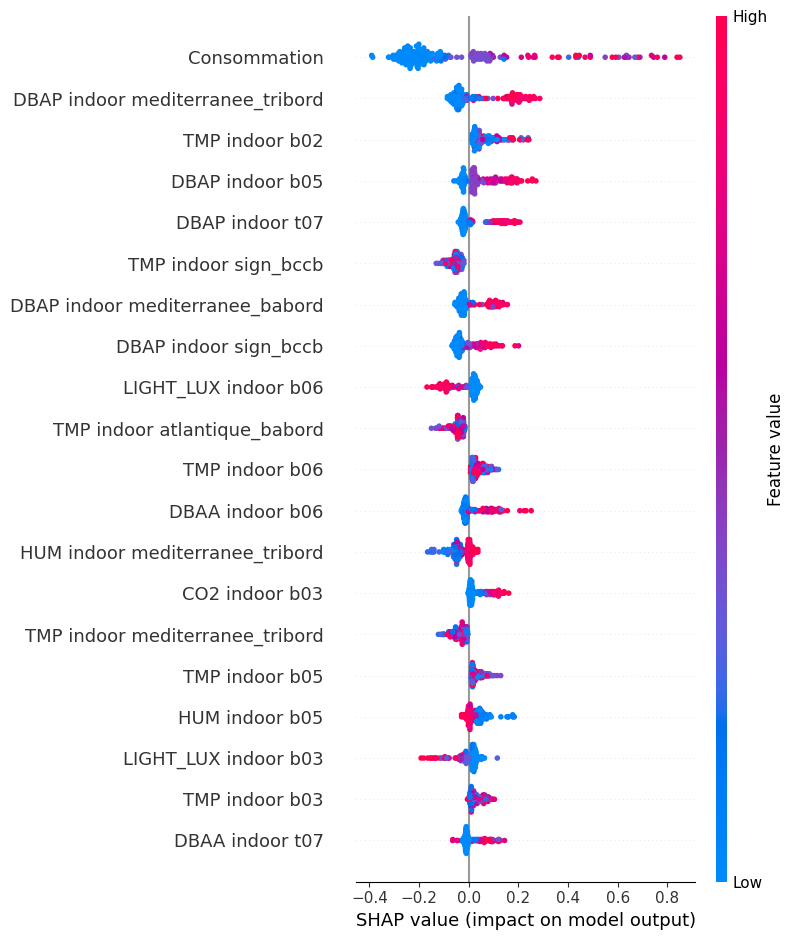

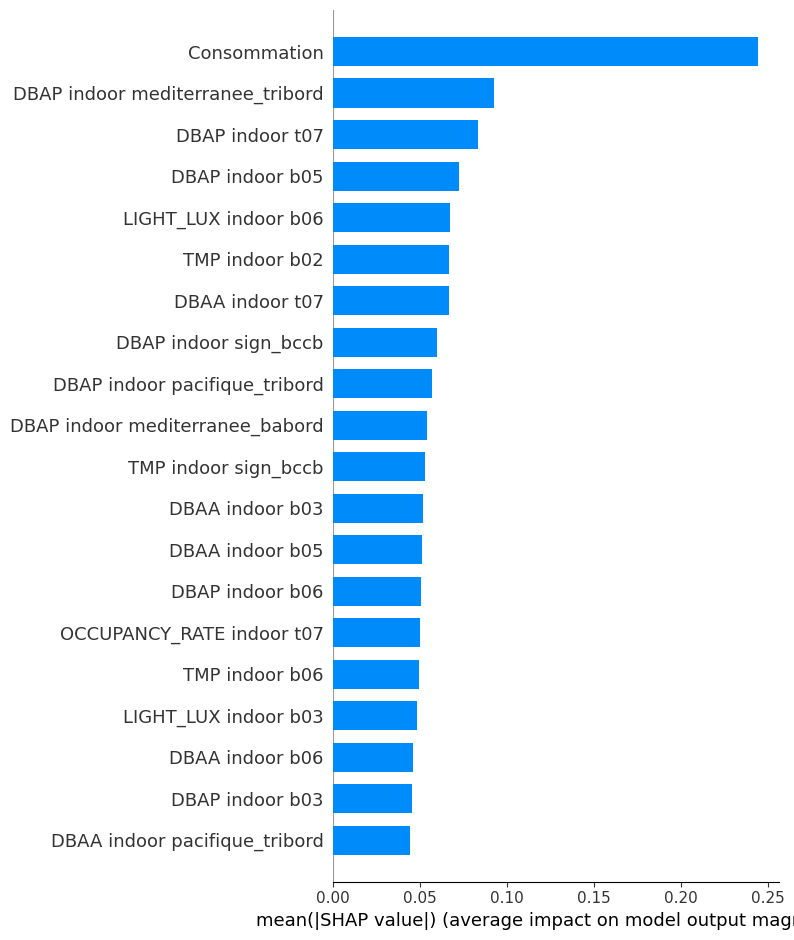

In [14]:
# Average each feature's value across the seq_length window so we have one
# value per feature per sequence -- this is what colors the beeswarm dots.
X_test_feature_values = test_seqs.mean(dim=1).numpy()  # shape: (n_explain, n_features)

# 1. Standard Beeswarm Plot (Red/Blue gradient for feature values)
shap.summary_plot(
    shap_per_feature_signed,      # (n_explain, n_features) signed, time-collapsed SHAP values
    features=X_test_feature_values,
    feature_names=feature_names,
    show=True
)

# 2. Bar Chart (mean |SHAP| magnitude per feature)
shap.summary_plot(
    shap_per_feature_abs,
    features=X_test_feature_values,
    plot_type="bar",
    feature_names=feature_names,
    show=True
)


Permutaion importance

Baseline Test MSE: 0.1660
Computing permutation importance (this may take a moment)...


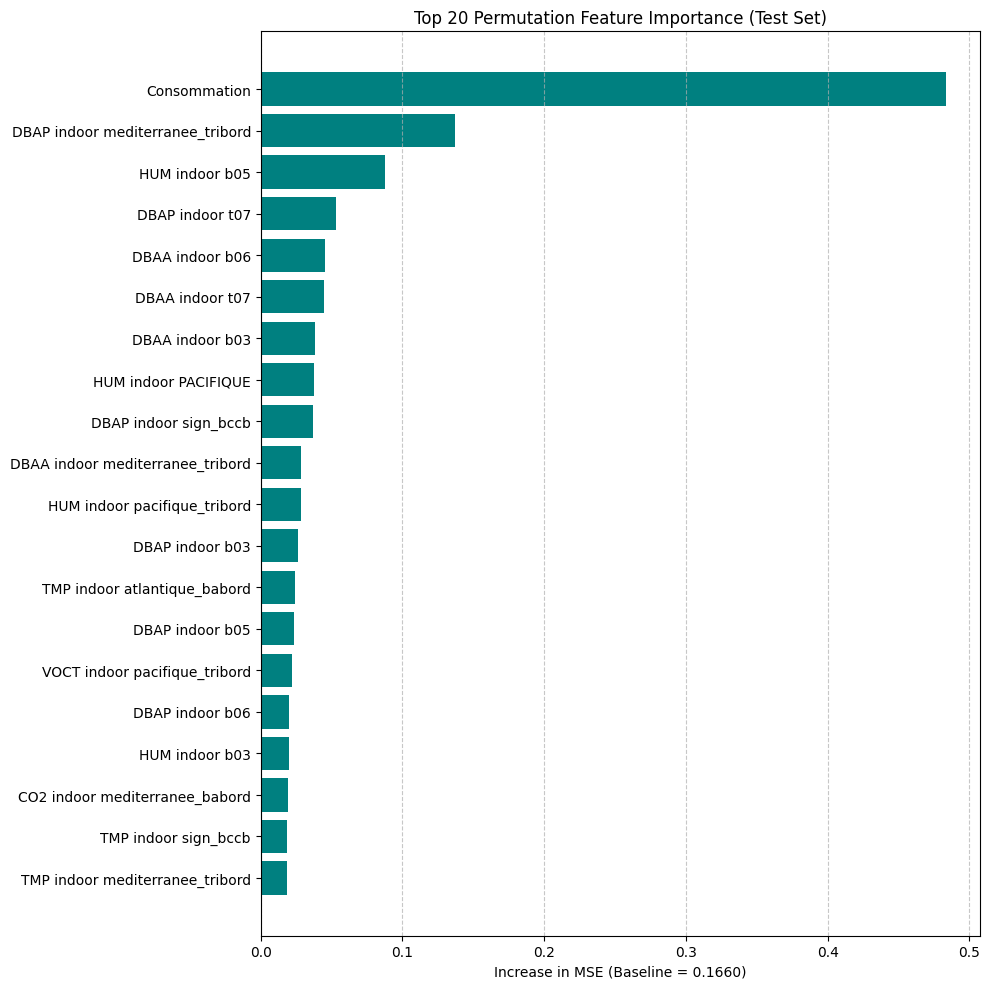


Top 10 Most Important Features:
                         feature  importance
                    Consommation    0.483309
DBAP indoor mediterranee_tribord    0.137034
                  HUM indoor b05    0.087674
                 DBAP indoor t07    0.052998
                 DBAA indoor b06    0.045049
                 DBAA indoor t07    0.044370
                 DBAA indoor b03    0.038071
            HUM indoor PACIFIQUE    0.037399
           DBAP indoor sign_bccb    0.037043
DBAA indoor mediterranee_tribord    0.028755


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ---------------------------------------------------------
# 1. Aggregate the Test Set into single Tensors
# ---------------------------------------------------------
X_test_list, y_test_list = [], []
for X_batch, y_batch in test_loader:
    X_test_list.append(X_batch)
    y_test_list.append(y_batch)

# Shape: (N_test, seq_length, n_features)
X_test = torch.cat(X_test_list, dim=0).to(device)
y_test = torch.cat(y_test_list, dim=0).to(device)

# ---------------------------------------------------------
# 2. Compute Baseline Metric (MSE)
# ---------------------------------------------------------
model.eval()
criterion = nn.MSELoss()

with torch.no_grad():
    y_pred_base = model(X_test).squeeze()
    
baseline_mse = criterion(y_pred_base, y_test).item()
print(f"Baseline Test MSE: {baseline_mse:.4f}")

# ---------------------------------------------------------
# 3. Compute Permutation Importance
# ---------------------------------------------------------
n_samples, seq_length, n_features = X_test.shape
importances = []
rng = np.random.default_rng(42) # For reproducibility

print("Computing permutation importance (this may take a moment)...")
for f in range(n_features):
    X_perm = X_test.clone()
    
    # Shuffle the feature 'f' across the samples (dimension 0).
    # This breaks the relationship between this feature's historical 
    # sequence and the target, while preserving the internal temporal 
    # dynamics of the feature itself.
    perm_idx = rng.permutation(n_samples)
    X_perm[:, :, f] = X_perm[perm_idx, :, f]
    
    with torch.no_grad():
        y_pred_perm = model(X_perm).squeeze()
        perm_mse = criterion(y_pred_perm, y_test).item()
        
    # Importance is the increase in error (MSE)
    importance = perm_mse - baseline_mse
    importances.append(importance)

# ---------------------------------------------------------
# 4. Visualize and Interpret
# ---------------------------------------------------------
feature_names = df_numeric.columns.tolist()
perm_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot Top 20 features to avoid clutter
top_n = 20
plot_df = perm_imp_df.head(top_n).iloc[::-1] # Reverse for horizontal bar chart

plt.figure(figsize=(10, 10))
plt.barh(plot_df['feature'], plot_df['importance'], color='teal')
plt.xlabel(f'Increase in MSE (Baseline = {baseline_mse:.4f})')
plt.title(f'Top {top_n} Permutation Feature Importance (Test Set)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print Top 10 to console
print("\nTop 10 Most Important Features:")
print(perm_imp_df.head(10).to_string(index=False))

NotFittedError: This LSTMSequenceWrapper instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

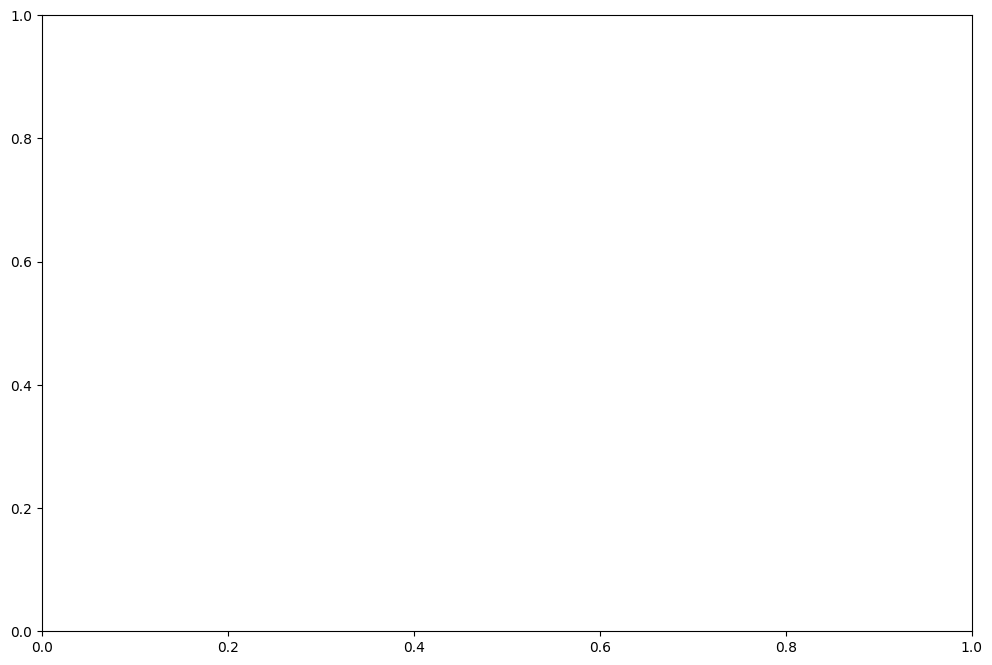

In [16]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import PartialDependenceDisplay

# ---------------------------------------------------------
# 1. Create the Scikit-Learn "Translator" Wrapper
# ---------------------------------------------------------
class LSTMSequenceWrapper(BaseEstimator, RegressorMixin):
    """
    Wraps the PyTorch LSTM so scikit-learn's PDP can use it.
    It accepts 2D data, expands it to 3D (repeating across the sequence), 
    runs the LSTM, and inverse-transforms the output to physical units.
    """
    def __init__(self, pytorch_model, seq_length, device, scaler, target_idx):
        self.pytorch_model = pytorch_model
        self.seq_length = seq_length
        self.device = device
        self.scaler = scaler
        self.target_idx = target_idx
        
    def fit(self, X, y=None):
        self.fitted_ = True  # Satisfies sklearn's internal validation
        return self  
        
    def predict(self, X):
        # 1. X is 2D from sklearn: (n_samples, n_features)
        # 2. Expand to 3D for LSTM: (n_samples, seq_length, n_features)
        # We repeat the 2D values across the time window.
        X_3d = np.repeat(X[:, np.newaxis, :], self.seq_length, axis=1)
        X_tensor = torch.tensor(X_3d, dtype=torch.float32).to(self.device)
        
        # 3. Run LSTM prediction
        self.pytorch_model.eval()
        with torch.no_grad():
            preds_scaled = self.pytorch_model(X_tensor).squeeze().cpu().numpy()
            
        # 4. Inverse transform to original physical units (e.g., kWh)
        target_mean = self.scaler.mean_[self.target_idx]
        target_scale = self.scaler.scale_[self.target_idx]
        return preds_scaled * target_scale + target_mean

# ---------------------------------------------------------
# 2. Prepare 2D Data for Scikit-Learn
# ---------------------------------------------------------
# Aggregate the 3D test sequences into 2D by taking the mean over the time window.
X_test_list = []
for X_batch, _ in test_loader:
    X_test_list.append(X_batch)
    
X_test_3d = torch.cat(X_test_list, dim=0).numpy()
X_test_2d = X_test_3d.mean(axis=1)  # Shape: (N_test, n_features)

# Subsample to keep the plot generation fast (sklearn evaluates the model many times)
rng = np.random.default_rng(42)
subset_idx = rng.choice(X_test_2d.shape[0], size=min(500, X_test_2d.shape[0]), replace=False)
X_test_2d_sub = X_test_2d[subset_idx]

# Convert to DataFrame so sklearn automatically uses the correct feature names on the axes
X_test_df = pd.DataFrame(X_test_2d_sub, columns=df_numeric.columns)

# ---------------------------------------------------------
# 3. Instantiate Wrapper and Plot PDP + ICE
# ---------------------------------------------------------
wrapper = LSTMSequenceWrapper(
    pytorch_model=model, 
    seq_length=seq_length, 
    device=device, 
    scaler=scaler, 
    target_idx=target_idx
)

# Pick top 3 features from your SHAP importance_df
top_features = importance_df['feature'].head(3).tolist()

fig, ax = plt.subplots(figsize=(12, 8))

# kind='both' plots the ICE curves (thin lines) AND the PDP (thick line)
PartialDependenceDisplay.from_estimator(
    wrapper, 
    X_test_df, 
    features=top_features,
    kind='both',         # Shows both ICE and PDP simultaneously
    grid_resolution=30,  # Number of points on the x-axis
    n_cols=2,            # Layout of the subplots
    ax=ax,
    line_kw={'color': 'dodgerblue', 'alpha': 0.2},  # ICE lines style
    pd_line_kw={'color': 'crimson', 'linewidth': 3}  # PDP line style
)

plt.suptitle('Partial Dependence & ICE Plots (Physical Units)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()